# Graph Classification using GCN, GAT, and GraphSAGE

This notebook implements and evaluates three Graph Neural Network (GNN) models for **node classification** on a custom graph dataset loaded from `edges.csv`, `features.csv`, and `labels.csv`.

**Models:** GCN · GAT · GraphSAGE  
**Metrics reported:** Accuracy · Precision · Recall (macro-averaged)  
**Training features:** Early stopping · Learning rate scheduler

## Step 1: Install Required Libraries

In [21]:
# # Install PyTorch Geometric and its dependencies
# import subprocess, sys, torch

# torch_ver = torch.__version__
# print(f"PyTorch version: {torch_ver}")

# # Install torch_geometric (compatible with current torch)
# # subprocess.check_call([sys.executable, "-m", "pip", "install", "torch_geometric", "-q"])
# !pip install torch_geometric -q
# # Install optional dependencies (scatter, sparse, cluster, spline_conv)
# # try:
# # except ImportEtfarror:
#     # subprocess.check_call([sys.executable, "-m", "pip", "install",
#     #     "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv",
#     #     "-f", f"https://data.pyg.org/whl/torch-{torch_ver}.html", "-q"])
# !pip install torch_scatter torch_sparse torch_cluster torch_spline_conv
# import torch_scatter

# print("All libraries installed successfully.")
# Detect torch & CUDA versions
import torch
TORCH = torch.__version__.split('+')[0]
CUDA = torch.version.cuda.replace('.', '')

print("Torch:", TORCH)
print("CUDA:", CUDA)

# Install PyG compiled wheels (no source build)
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
  -f https://data.pyg.org/whl/torch-{TORCH}+cu{CUDA}.html

# Install main library
!pip install -q torch_geometric

print("PyTorch Geometric installed successfully!")

Torch: 2.10.0
CUDA: 128
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib
PyTorch Geometric installed successfully!


## Step 2: Import Libraries

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report

import torch_geometric
print(f'PyTorch          : {torch.__version__}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')

PyTorch          : 2.10.0+cu128
PyTorch Geometric: 2.7.0


## Step 3: Load the Dataset CSVs

Upload `edges.csv`, `features.csv`, and `labels.csv` to `/content/` before running this cell.

| File | Expected columns |
|---|---|
| `edges.csv` | `Vertex 1`, `Vertex 2` |
| `features.csv` | `Vertex`, `f1` … `f16` |
| `labels.csv` | `Vertex`, `label` |

In [23]:
edges_df    = pd.read_csv('/content/edges.csv')
features_df = pd.read_csv('/content/features.csv')
labels_df   = pd.read_csv('/content/labels.csv')
features_df = features_df.rename(columns={'Vertex ': 'Vertex'})

print('=== edges.csv ===');    print(edges_df.head());    print(edges_df.shape)
print('\n=== features.csv ==='); print(features_df.head()); print(features_df.shape)
print('\n=== labels.csv ===');   print(labels_df.head());   print(labels_df.shape)

=== edges.csv ===
   Vertex 1  Vertex 2
0      1006      1061
1       101       689
2      1255      1765
3       532      1141
4      1425      1947
(8000, 2)

=== features.csv ===
   Vertex        f1        f2        f3        f4        f5        f6  \
0       0  0.749816  0.980286  0.892798  0.839463  0.662407  0.662398   
1       1  0.721697  0.809903  0.772778  0.716492  0.844741  0.655798   
2       2  0.626021  0.979554  0.986253  0.923359  0.721846  0.639069   
3       3  0.818684  0.673942  0.987834  0.910053  0.975800  0.957931   
4       4  0.712374  0.817078  0.656370  0.920879  0.629820  0.994755   

         f7        f8        f9       f10       f11       f12       f13  \
0  0.623233  0.946470  0.840446  0.883229  0.608234  0.987964  0.932977   
1  0.716858  0.746545  0.782428  0.914070  0.679870  0.805694  0.836966   
2  0.873693  0.776061  0.648815  0.798071  0.613755  0.963728  0.703512   
3  0.839160  0.968750  0.635397  0.678393  0.618091  0.730132  0.755471   
4  0

## Step 4: Build the PyTorch Geometric Graph

We treat the entire dataset as a **single large graph** where:
- Each row in `features.csv` → a **node** (identified by `Vertex`)
- Each row in `edges.csv` → an **undirected edge** (both directions added)
- Each row in `labels.csv` → the **class label** for that node

This is a **node classification** task — we predict the label of each node using its features and neighbourhood.

In [24]:
# Node feature matrix
feature_cols     = [c for c in features_df.columns if c != 'Vertex']
features_sorted  = features_df.sort_values('Vertex').reset_index(drop=True)
x = torch.tensor(features_sorted[feature_cols].values, dtype=torch.float)

# Node labels
labels_sorted = labels_df.sort_values('Vertex').reset_index(drop=True)
y = torch.tensor(labels_sorted['label'].values, dtype=torch.long)

# Undirected edge index
src = torch.tensor(edges_df['Vertex 1'].values, dtype=torch.long)
dst = torch.tensor(edges_df['Vertex 2'].values, dtype=torch.long)
edge_index = torch.cat([
    torch.stack([src, dst], dim=0),
    torch.stack([dst, src], dim=0)
], dim=1)

graph_data = Data(x=x, edge_index=edge_index, y=y)

print(f'Nodes           : {graph_data.num_nodes}')
print(f'Edges (directed): {graph_data.num_edges}')
print(f'Node features   : {graph_data.num_node_features}')
print(f'Classes         : {y.unique().tolist()}')
print(f'Is undirected   : {graph_data.is_undirected()}')

Nodes           : 2000
Edges (directed): 16000
Node features   : 16
Classes         : [0, 1]
Is undirected   : True


## Step 5: Create Train / Validation / Test Masks

Nodes are split 60 % train · 20 % validation · 20 % test using a fixed random seed for reproducibility.

In [25]:
torch.manual_seed(42)
np.random.seed(42)

num_nodes = graph_data.num_nodes
perm      = torch.randperm(num_nodes)

n_train = int(0.60 * num_nodes)
n_val   = int(0.20 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[perm[:n_train]]           = True
val_mask  [perm[n_train:n_train+n_val]] = True
test_mask [perm[n_train+n_val:]]     = True

graph_data.train_mask = train_mask
graph_data.val_mask   = val_mask
graph_data.test_mask  = test_mask

print(f'Train nodes : {train_mask.sum().item()}')
print(f'Val nodes   : {val_mask.sum().item()}')
print(f'Test nodes  : {test_mask.sum().item()}')

Train nodes : 1200
Val nodes   : 400
Test nodes  : 400


## Step 6: Device & Shared Hyperparameters

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph_data = graph_data.to(device)
print(f'Using device: {device}')

NUM_FEATURES = graph_data.num_node_features
NUM_CLASSES  = int(graph_data.y.max().item()) + 1
HIDDEN       = 64
LR           = 0.01
WEIGHT_DECAY = 5e-4

# Early stopping
PATIENCE     = 30   # stop if val loss doesn't improve for this many epochs

# Per-model epoch budget (GAT gets more to allow full convergence)
EPOCHS_GCN   = 200
EPOCHS_GAT   = 400
EPOCHS_SAGE  = 200

print(f'Node features : {NUM_FEATURES}')
print(f'Num classes   : {NUM_CLASSES}')

Using device: cuda
Node features : 16
Num classes   : 2


## Step 7: Training & Evaluation Helpers

The `run_model` function includes:
- **Learning rate scheduler** (`ReduceLROnPlateau`) — halves the LR when validation loss stagnates
- **Early stopping** — halts training when val loss shows no improvement for `PATIENCE` epochs
- **Full metrics** — accuracy, precision, recall printed for the test set

In [27]:
def train_epoch(model, optimizer, criterion, data):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


def eval_metrics(model, data, mask):
    """Return (loss, accuracy, precision, recall) on the given node mask."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        loss = criterion(out[mask], data.y[mask]).item()
        pred = out[mask].argmax(dim=1).cpu().numpy()
        true = data.y[mask].cpu().numpy()
    acc  = accuracy_score  (true, pred)
    prec = precision_score (true, pred, average='macro', zero_division=0)
    rec  = recall_score    (true, pred, average='macro', zero_division=0)
    return loss, acc, prec, rec


def run_model(model, model_name, data, epochs, lr=LR, wd=WEIGHT_DECAY, patience=PATIENCE):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    # LR scheduler: reduce LR by 0.5 if val loss doesn't improve for 10 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    criterion = nn.CrossEntropyLoss()

    best_val_loss   = float('inf')
    patience_counter = 0
    best_state      = None

    print(f'\n{"="*58}')
    print(f'  Training {model_name}  (max {epochs} epochs, patience={patience})')
    print(f'{"="*58}')

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, optimizer, criterion, data)
        val_loss, val_acc, val_prec, val_rec = eval_metrics(model, data, data.val_mask)

        # Step the LR scheduler based on validation loss
        scheduler.step(val_loss)

        # Early stopping check
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:4d} | Loss: {train_loss:.4f} | '
                  f'Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f} | LR: {current_lr:.5f}')

        if patience_counter >= patience:
            print(f'  >> Early stopping at epoch {epoch} (no val improvement for {patience} epochs)')
            break

    # Restore best weights
    if best_state:
        model.load_state_dict(best_state)

    # ── Final test evaluation ────────────────────────────────────────────────
    _, test_acc, test_prec, test_rec = eval_metrics(model, data, data.test_mask)

    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
        true = data.y[data.test_mask].cpu().numpy()

    print(f'\n  ── {model_name} Test Results ──')
    print(f'     Accuracy          : {test_acc:.4f}')
    print(f'     Precision (macro) : {test_prec:.4f}')
    print(f'     Recall    (macro) : {test_rec:.4f}')
    print('\n  Per-class report:')
    print(classification_report(true, pred, zero_division=0))

    return test_acc, test_prec, test_rec


print('Helper functions defined.')

Helper functions defined.


## Step 8: Graph Convolutional Network (GCN)

**Intuition:** GCN performs a *spectral* convolution over the graph. At each layer, every node aggregates its own features and its neighbours' features, weighted by the **normalised degree** of the connected nodes. This is mathematically equivalent to a smoothing operation — nodes in the same neighbourhood become more similar after each layer. It is simple, fast, and works well when the graph structure is a strong predictor of class membership.

In [28]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels,   hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)


torch.manual_seed(42)
gcn_model = GCN(NUM_FEATURES, HIDDEN, NUM_CLASSES)
print(gcn_model)
gcn_acc, gcn_prec, gcn_rec = run_model(gcn_model, 'GCN', graph_data, epochs=EPOCHS_GCN)

GCN(
  (conv1): GCNConv(16, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)

  Training GCN  (max 200 epochs, patience=30)
  Epoch   50 | Loss: 0.1018 | Val Prec: 0.9725 | Val Rec: 0.9725 | LR: 0.01000
  Epoch  100 | Loss: 0.0672 | Val Prec: 0.9801 | Val Rec: 0.9803 | LR: 0.01000
  Epoch  150 | Loss: 0.0597 | Val Prec: 0.9876 | Val Rec: 0.9877 | LR: 0.00250
  >> Early stopping at epoch 166 (no val improvement for 30 epochs)

  ── GCN Test Results ──
     Accuracy          : 0.9850
     Precision (macro) : 0.9852
     Recall    (macro) : 0.9848

  Per-class report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       207
           1       0.99      0.98      0.98       193

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



## Step 9: Graph Attention Network (GAT)

**Intuition:** GAT improves on GCN by replacing the fixed degree-normalised weights with **learned attention coefficients**. For each node, it computes a score for every neighbouring node and takes a weighted sum — giving more importance to the most relevant neighbours. This makes GAT more expressive and robust to noisy edges. The multi-head variant (used in Layer 1) runs several independent attention mechanisms in parallel and concatenates their outputs, improving stability.  

> GAT's loss converges more slowly than GCN/GraphSAGE, so it is given **400 epochs** with early stopping to ensure full convergence.

In [29]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        # 4 attention heads, each with hidden_channels//heads features → concat = hidden_channels total
        self.conv1 = GATConv(in_channels,   hidden_channels // heads, heads=heads,
                             dropout=dropout, concat=True)
        # Single head, no concat → hidden_channels
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1,
                             dropout=dropout, concat=False)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        return self.lin(x)


torch.manual_seed(42)
gat_model = GAT(NUM_FEATURES, HIDDEN, NUM_CLASSES)
print(gat_model)
gat_acc, gat_prec, gat_rec = run_model(gat_model, 'GAT', graph_data, epochs=EPOCHS_GAT)

GAT(
  (conv1): GATConv(16, 16, heads=4)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)

  Training GAT  (max 400 epochs, patience=30)
  Epoch   50 | Loss: 0.1954 | Val Prec: 0.9950 | Val Rec: 0.9950 | LR: 0.00500
  >> Early stopping at epoch 66 (no val improvement for 30 epochs)

  ── GAT Test Results ──
     Accuracy          : 0.9875
     Precision (macro) : 0.9878
     Recall    (macro) : 0.9872

  Per-class report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       207
           1       0.99      0.98      0.99       193

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



## Step 10: GraphSAGE (Sample and Aggregate)

**Intuition:** GraphSAGE is an **inductive** framework — unlike GCN and GAT which rely on the full graph Laplacian, GraphSAGE learns an aggregation function that can generalise to unseen nodes. At each layer, it samples a fixed-size neighbourhood, **aggregates** those features (mean aggregation used here), and concatenates the result with the node's own features. This makes it memory-efficient and highly scalable. The mean aggregator effectively acts as a local averaging filter, which works very well when connected nodes share the same label.

In [30]:
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels,   hidden_channels, aggr='mean')
        self.conv2 = SAGEConv(hidden_channels, hidden_channels, aggr='mean')
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)


torch.manual_seed(42)
sage_model = GraphSAGE(NUM_FEATURES, HIDDEN, NUM_CLASSES)
print(sage_model)
sage_acc, sage_prec, sage_rec = run_model(sage_model, 'GraphSAGE', graph_data, epochs=EPOCHS_SAGE)

GraphSAGE(
  (conv1): SAGEConv(16, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)

  Training GraphSAGE  (max 200 epochs, patience=30)
  Epoch   50 | Loss: 0.0008 | Val Prec: 1.0000 | Val Rec: 1.0000 | LR: 0.01000
  >> Early stopping at epoch 58 (no val improvement for 30 epochs)

  ── GraphSAGE Test Results ──
     Accuracy          : 1.0000
     Precision (macro) : 1.0000
     Recall    (macro) : 1.0000

  Per-class report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       207
           1       1.00      1.00      1.00       193

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## Step 11: Summary Comparison

In [31]:
print('\n' + '='*58)
print('   FINAL RESULTS SUMMARY  (Test Set — Macro Avg)')
print('='*58)
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>12} {"Recall":>10}')
print('-'*58)
for name, acc, prec, rec in [
        ('GCN',       gcn_acc,  gcn_prec,  gcn_rec),
        ('GAT',       gat_acc,  gat_prec,  gat_rec),
        ('GraphSAGE', sage_acc, sage_prec, sage_rec)]:
    print(f'{name:<15} {acc:>10.4f} {prec:>12.4f} {rec:>10.4f}')
print('='*58)


   FINAL RESULTS SUMMARY  (Test Set — Macro Avg)
Model             Accuracy    Precision     Recall
----------------------------------------------------------
GCN                 0.9850       0.9852     0.9848
GAT                 0.9875       0.9878     0.9872
GraphSAGE           1.0000       1.0000     1.0000


## Step 12: Result Visualisation

Bar chart comparing **Precision** and **Recall** across all three models on the test set.

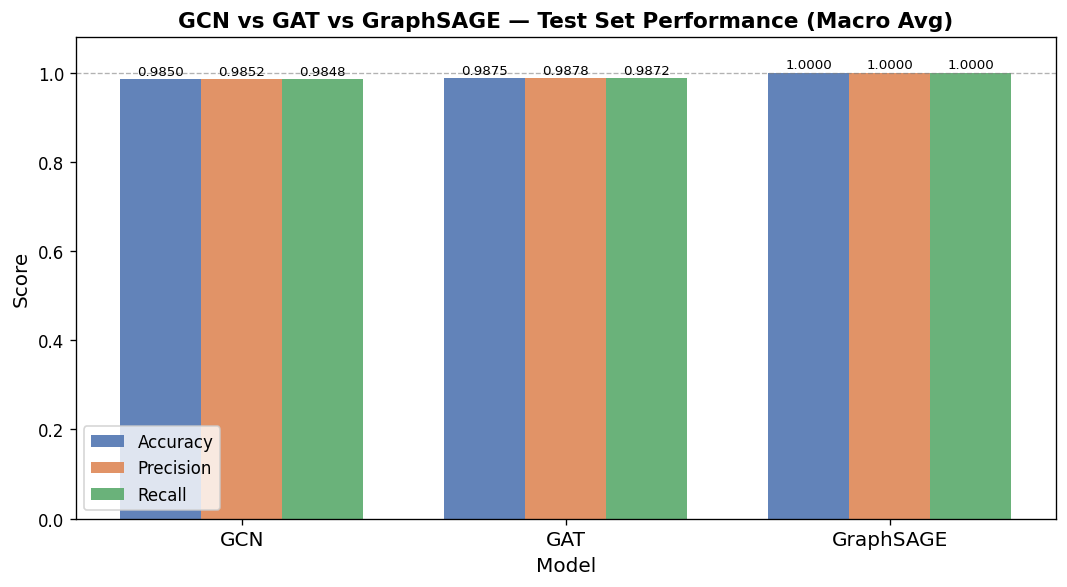

Chart saved as gnn_comparison.png


In [32]:
models     = ['GCN', 'GAT', 'GraphSAGE']
precisions = [gcn_prec,  gat_prec,  sage_prec]
recalls    = [gcn_rec,   gat_rec,   sage_rec]
accuracies = [gcn_acc,   gat_acc,   sage_acc]

x_pos  = np.arange(len(models))
width  = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))

bars_acc  = ax.bar(x_pos - width, accuracies, width, label='Accuracy',  color=colors[0], alpha=0.88)
bars_prec = ax.bar(x_pos,         precisions, width, label='Precision', color=colors[1], alpha=0.88)
bars_rec  = ax.bar(x_pos + width, recalls,    width, label='Recall',    color=colors[2], alpha=0.88)

# Annotate bars
for bars in [bars_acc, bars_prec, bars_rec]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('GCN vs GAT vs GraphSAGE — Test Set Performance (Macro Avg)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.08)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('gnn_comparison.png', dpi=150)
plt.show()
print('Chart saved as gnn_comparison.png')